# Predictive Maintenance using Machine Learning

This project aims to predict machine failures using industrial sensor data and machine learning models to support predictive maintenance and reduce unexpected downtime.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

The dataset contains operational and sensor data from industrial machines, including temperature, rotational speed, torque, and tool wear measurements.

In [2]:
df = pd.read_csv("predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Data Inspection and Cleaning

In [3]:
df.columns = [
    'udi',
    'product_id',
    'type',
    'air_temp_k',
    'process_temp_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min',
    'machine_failure',
    'twf',
    'hdf',
    'pwf',
    'osf',
    'rnf'
]

df.head()

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df['machine_failure'].value_counts())

print("\nTarget percentage:")
print(df['machine_failure'].value_counts(normalize=True) * 100)

Shape: (10000, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   udi                   10000 non-null  int64  
 1   product_id            10000 non-null  object 
 2   type                  10000 non-null  object 
 3   air_temp_k            10000 non-null  float64
 4   process_temp_k        10000 non-null  float64
 5   rotational_speed_rpm  10000 non-null  int64  
 6   torque_nm             10000 non-null  float64
 7   tool_wear_min         10000 non-null  int64  
 8   machine_failure       10000 non-null  int64  
 9   twf                   10000 non-null  int64  
 10  hdf                   10000 non-null  int64  
 11  pwf                   10000 non-null  int64  
 12  osf                   10000 non-null  int64  
 13  rnf                   10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
me

# Feature Engineering

In [5]:
df.describe()

,udi,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df['temp_difference'] = df['process_temp_k'] - df['air_temp_k']

df[['air_temp_k', 'process_temp_k', 'temp_difference']].head()

,air_temp_k,process_temp_k,temp_difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [7]:
failure_comparison = df.groupby('machine_failure')[
    [
        'air_temp_k',
        'process_temp_k',
        'rotational_speed_rpm',
        'torque_nm',
        'tool_wear_min',
        'temp_difference'
    ]
].mean()

failure_comparison

,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_difference
machine_failure,,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717,10.021571
1,300.886431,310.290265,1496.486726,50.168142,143.781711,9.403835


# Exploratory Data Analysis

In [8]:
type_failure = df.groupby('type')['machine_failure'].agg(['count', 'sum', 'mean'])
type_failure['failure_rate_percent'] = type_failure['mean'] * 100

type_failure

,count,sum,mean,failure_rate_percent
type,,,,
H,1003,21,0.020937,2.093719
L,6000,235,0.039167,3.916667
M,2997,83,0.027694,2.769436


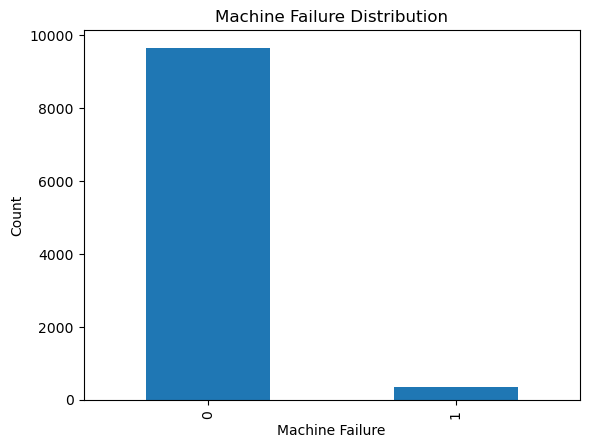

In [9]:
df['machine_failure'].value_counts().plot(kind='bar')
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

In [10]:
X = df.drop(columns=[
    'udi',
    'product_id',
    'machine_failure',
    'twf',
    'hdf',
    'pwf',
    'osf',
    'rnf'
])

y = df['machine_failure']

X.head()

,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_difference
0,M,298.1,308.6,1551,42.8,0,10.5
1,L,298.2,308.7,1408,46.3,3,10.5
2,L,298.1,308.5,1498,49.4,5,10.4
3,L,298.2,308.6,1433,39.5,7,10.4
4,L,298.2,308.7,1408,40.0,9,10.5


In [11]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

X.head()

,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_difference,type_L,type_M
0,298.1,308.6,1551,42.8,0,10.5,False,True
1,298.2,308.7,1408,46.3,3,10.5,True,False
2,298.1,308.5,1498,49.4,5,10.4,True,False
3,298.2,308.6,1433,39.5,7,10.4,True,False
4,298.2,308.7,1408,40.0,9,10.5,True,False


# Model Training

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (8000, 8)
Test set: (2000, 8)

Training target distribution:
machine_failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test target distribution:
machine_failure
0    96.6
1     3.4
Name: proportion, dtype: float64


# Logistic Regression Evaluation

In [13]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

log_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [14]:
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

print("ROC-AUC:", roc_auc_score(y_test, log_proba))

Logistic Regression Results

Confusion Matrix:
[[1596  336]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.83      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC: 0.9069312507611741


# Random Forest Evaluation

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The models were evaluated using precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [16]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest Results

Confusion Matrix:
[[1929    3]
 [  27   41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.60      0.73        68

    accuracy                           0.98      2000
   macro avg       0.96      0.80      0.86      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9688946230666181


In [17]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [
        roc_auc_score(y_test, log_proba),
        roc_auc_score(y_test, rf_proba)
    ]
})

model_comparison

,Model,ROC_AUC
0,Logistic Regression,0.906931
1,Random Forest,0.968895


# Feature Importance Analysis

In [18]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
3,torque_nm,0.288926
2,rotational_speed_rpm,0.277722
4,tool_wear_min,0.202804
5,temp_difference,0.093145
0,air_temp_k,0.068521
1,process_temp_k,0.052000
6,type_L,0.009608
7,type_M,0.007275


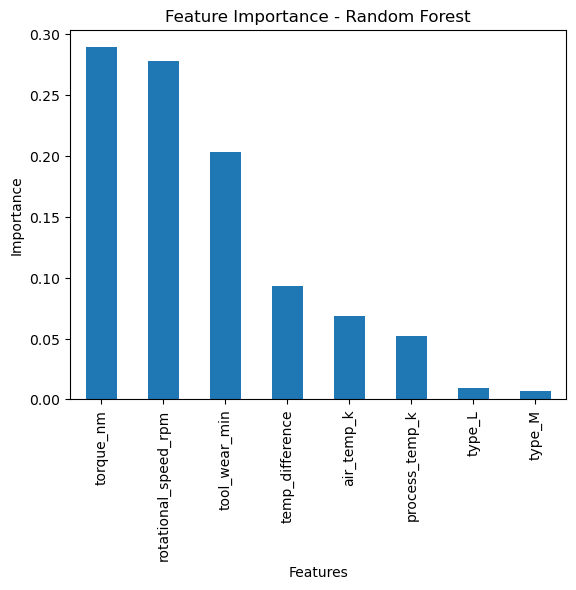

In [19]:
feature_importance.plot(
    x='feature',
    y='importance',
    kind='bar',
    legend=False
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Key Insights
- The dataset was highly imbalanced, with only 3.39% failure cases.
- Failed machines showed higher average torque and tool wear.
- Rotational speed and torque were among the strongest predictors of machine failure.
- Random Forest achieved strong performance with high ROC-AUC.

# Business Impact

This predictive maintenance model can help maintenance teams identify high-risk machines earlier, reduce unexpected downtime, and improve maintenance planning efficiency.